# Cluster 2

In [150]:
import pandas as pd
import numpy as np
import random
import os

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

In [151]:
df = pd.read_csv('../../Clusters/cluster_2.csv')

In [152]:
df.head()

,Index,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Cluster
0,3,0,0.483401,0.556694,0.536164,0.602445,0.602445,0.999035,0.797458,0.809380,...,0.002177,0.621610,0.602444,0.841891,0.293391,0.027063,0.566190,1,0.015406,2
1,6,0,0.465071,0.533689,0.516944,0.594740,0.594740,0.998962,0.797393,0.809313,...,0.054013,0.613323,0.594736,0.840085,0.285529,0.029521,0.568791,1,0.019155,2
2,11,0,0.442500,0.507196,0.494941,0.598906,0.598812,0.998927,0.797298,0.809236,...,0.009173,0.624087,0.598903,0.838903,0.278959,0.026643,0.564335,1,0.032862,2
3,15,0,0.445230,0.500273,0.500990,0.601277,0.601277,0.998940,0.797289,0.809233,...,0.002127,0.623572,0.601277,0.837951,0.282391,0.026686,0.564603,1,0.022788,2
4,37,0,0.491201,0.556095,0.544944,0.599728,0.599728,0.999011,0.797414,0.809335,...,0.003267,0.622668,0.599728,0.840690,0.282521,0.028464,0.568246,1,0.022580,2


In [153]:
print(df.shape)
df.describe()

(904, 98)


,Index,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Cluster
count,904.000000,904.000000,904.000000,904.000000,904.000000,904.000000,904.000000,904.000000,904.000000,904.000000,...,9.040000e+02,904.000000,904.000000,904.000000,904.000000,904.000000,904.000000,904.0,904.000000,904.0
mean,2842.140487,0.111726,0.454117,0.506552,0.502734,0.603107,0.603115,0.998906,0.797240,0.809175,...,4.846239e+07,0.623500,0.603105,0.834917,0.286594,0.029445,0.565089,1.0,0.023270,2.0
std,1663.201376,0.315203,0.058792,0.070122,0.064373,0.010743,0.010746,0.000856,0.001030,0.000968,...,5.924934e+08,0.003325,0.010743,0.037129,0.032529,0.026484,0.013683,0.0,0.006746,0.0
min,3.000000,0.000000,0.000000,0.006923,0.000000,0.448342,0.448342,0.973875,0.767759,0.781429,...,1.015560e-04,0.591033,0.448342,0.000000,0.276702,0.021582,0.319590,1.0,0.010365,2.0
25%,1358.750000,0.000000,0.435187,0.484409,0.481784,0.598178,0.598176,0.998903,0.797234,0.809171,...,8.545638e-04,0.623363,0.598179,0.836821,0.280625,0.026646,0.564535,1.0,0.018816,2.0
50%,2835.000000,0.000000,0.469410,0.527775,0.520370,0.602445,0.602427,0.998967,0.797357,0.809285,...,1.724900e-03,0.623665,0.602444,0.839606,0.282761,0.026779,0.565158,1.0,0.022212,2.0
75%,4275.000000,0.000000,0.489945,0.548585,0.541290,0.607073,0.607124,0.999011,0.797420,0.809341,...,4.034450e-03,0.623804,0.607070,0.840741,0.285957,0.027225,0.566860,1.0,0.026518,2.0
max,5802.000000,1.000000,0.574367,0.635794,0.630708,0.657778,0.657778,0.999309,0.797801,0.809703,...,9.820000e+09,0.690700,0.657775,0.846063,1.000000,0.540672,0.664336,1.0,0.058145,2.0


Notice than some features are normalized between 0 and 1. Some features such as "Total assets to GNP price" are not normalized with some samples having larges values. All features seem to be numerical

In [154]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 904 entries, 0 to 903
Data columns (total 98 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Index                                                    904 non-null    int64  
 1   Bankrupt?                                                904 non-null    int64  
 2   ROA(C) before interest and depreciation before interest  904 non-null    float64
 3   ROA(A) before interest and % after tax                   904 non-null    float64
 4   ROA(B) before interest and depreciation after tax        904 non-null    float64
 5   Operating Gross Margin                                   904 non-null    float64
 6   Realized Sales Gross Margin                              904 non-null    float64
 7   Operating Profit Rate                                    904 non-null    float64
 8   Pre-tax net Interest Rate                

In [155]:
# Find number and percentage of companies with Bankrupt? = 1
bankrupt_count = (df["Bankrupt?"] == 1).sum()
total_count = len(df)
bankrupt_percentage = (bankrupt_count / total_count) * 100

print("Bankruptcy Distribution:")
print("="*60)
print(f"Companies with Bankrupt? = 1: {bankrupt_count}")
print(f"Companies with Bankrupt? = 0: {total_count - bankrupt_count}")
print(f"Total companies: {total_count}")
print(f"\nBankruptcy Rate: {bankrupt_percentage:.2f}%")
print(f"Non-bankruptcy Rate: {100 - bankrupt_percentage:.2f}%")

Bankruptcy Distribution:
Companies with Bankrupt? = 1: 101
Companies with Bankrupt? = 0: 803
Total companies: 904

Bankruptcy Rate: 11.17%
Non-bankruptcy Rate: 88.83%


## Boolean features

In [156]:
df["Net Income Flag"].describe()

count    904.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: Net Income Flag, dtype: float64

In [157]:
# Check unique values for Net Income Flag
print("Unique values in Net Income Flag:")
print(df["Net Income Flag"].unique())
print(f"\nValue counts for Net Income Flag:")
print(df["Net Income Flag"].value_counts())
print(f"\nTotal samples: {len(df)}")
print(f"Samples with Net Income Flag = 1: {(df['Net Income Flag'] == 1).sum()}")
print(f"All values are 1: {(df['Net Income Flag'] == 1).all()}")

Unique values in Net Income Flag:
[1]

Value counts for Net Income Flag:
Net Income Flag
1    904
Name: count, dtype: int64

Total samples: 904
Samples with Net Income Flag = 1: 904
All values are 1: True


In [158]:
df["Liability-Assets Flag"].describe()

count    904.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Liability-Assets Flag, dtype: float64

In [159]:
# Check unique values for Net Income Flag
print("Unique values in Liability-Assets Flag:")
print(df["Liability-Assets Flag"].unique())
print(f"\nValue counts for Liability-Assets Flag:")
print(df["Liability-Assets Flag"].value_counts())
print(f"\nTotal samples: {len(df)}")
print(f"Samples with Liability-Assets Flag = 1: {(df['Liability-Assets Flag'] == 1).sum()}")
print(f"All values are 0: {(df['Liability-Assets Flag'] == 0).all()}")

Unique values in Liability-Assets Flag:
[0]

Value counts for Liability-Assets Flag:
Liability-Assets Flag
0    904
Name: count, dtype: int64

Total samples: 904
Samples with Liability-Assets Flag = 1: 0
All values are 0: True


We have two categorical (boolean) features Net Income Flag and Liability-Assets Flag. Both features are heavily skewed.

## Identify Constant features

In [160]:
# Identify constant features (features with only one unique value)
constant_features = []
for col in df.columns:
    if df[col].nunique() == 1:
        constant_features.append(col)

print(f"Constant features found: {len(constant_features)}\n")
if constant_features:
    for feature in constant_features:
        unique_val = df[feature].unique()[0]
        print(f"  - {feature}: {unique_val}")
else:
    print("No constant features found.")

Constant features found: 3

  - Liability-Assets Flag: 0
  - Net Income Flag: 1
  - Cluster: 2


## Drop constant features and index

In [161]:
df = df.drop(columns=["Index", "Liability-Assets Flag", "Net Income Flag", "Cluster"])
df.shape

(904, 94)

In [162]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Current Liability to Current Assets,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability
0,0,0.483401,0.556694,0.536164,0.602445,0.602445,0.999035,0.797458,0.809380,0.303506,...,0.034617,0.806477,0.002177,0.621610,0.602444,0.841891,0.293391,0.027063,0.566190,0.015406
1,0,0.465071,0.533689,0.516944,0.594740,0.594740,0.998962,0.797393,0.809313,0.303544,...,0.034854,0.796315,0.054013,0.613323,0.594736,0.840085,0.285529,0.029521,0.568791,0.019155
2,0,0.442500,0.507196,0.494941,0.598906,0.598812,0.998927,0.797298,0.809236,0.303453,...,0.025404,0.780905,0.009173,0.624087,0.598903,0.838903,0.278959,0.026643,0.564335,0.032862
3,0,0.445230,0.500273,0.500990,0.601277,0.601277,0.998940,0.797289,0.809233,0.303410,...,0.040409,0.774922,0.002127,0.623572,0.601277,0.837951,0.282391,0.026686,0.564603,0.022788
4,0,0.491201,0.556095,0.544944,0.599728,0.599728,0.999011,0.797414,0.809335,0.303479,...,0.058151,0.802420,0.003267,0.622668,0.599728,0.840690,0.282521,0.028464,0.568246,0.022580


## Missing Values Analysis

In [163]:
# Check for missing values
print("Missing values summary:")
print("="*50)
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Create summary dataframe
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_values.values,
    'Missing %': missing_percent.values
})

# Filter to show only columns with missing values
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_summary) == 0:
    print("\n✓ No missing values found in the dataset!")
else:
    print(f"\nFound {len(missing_summary)} columns with missing values:\n")
    print(missing_summary.to_string(index=False))

print(f"\n{'='*50}")
print(f"Total samples: {len(df)}")
print(f"Total features: {len(df.columns)}")

Missing values summary:

✓ No missing values found in the dataset!

Total samples: 904
Total features: 94


## Feature Normalization Analysis

In [164]:
# Identify features NOT normalized between 0 and 1
non_normalized = []
normalization_summary = []

for col in df.columns:
    if col == "Bankrupt?":  # Skip target variable
        continue
    
    min_val = df[col].min()
    max_val = df[col].max()
    is_normalized = (min_val >= 0) and (max_val <= 1)
    
    normalization_summary.append({
        'Feature': col,
        'Min': min_val,
        'Max': max_val,
        'Normalized': 'Yes' if is_normalized else 'No'
    })
    
    if not is_normalized:
        non_normalized.append(col)

# Create summary dataframe
norm_df = pd.DataFrame(normalization_summary)
non_norm_df = norm_df[norm_df['Normalized'] == 'No'].sort_values('Min')

print(f"Features NOT normalized between 0 and 1: {len(non_normalized)}\n")
print(non_norm_df.to_string(index=False))
print(f"\n{'='*80}")
print(f"Features normalized between 0 and 1: {len(norm_df) - len(non_normalized)}")
print(f"Total features: {len(norm_df)}")

Features NOT normalized between 0 and 1: 15

                              Feature      Min          Max Normalized
Research and development expense rate 0.000000 9.920000e+09         No
  Interest-bearing debt interest rate 0.000000 4.700000e+08         No
Long-term Liability to Current Assets 0.000000 9.030000e+09         No
          Inventory/Current Liability 0.000000 5.280000e+09         No
          Current Asset Turnover Rate 0.000000 9.980000e+09         No
               Operating Expense Rate 0.000100 9.970000e+09         No
            Quick Asset Turnover Rate 0.000100 1.000000e+10         No
      Inventory Turnover Rate (times) 0.000100 9.990000e+09         No
              Total Asset Growth Rate 0.000100 9.880000e+09         No
      Fixed Assets Turnover Frequency 0.000101 9.910000e+09         No
                   Cash Turnover Rate 0.000101 9.990000e+09         No
            Total assets to GNP price 0.000102 9.820000e+09         No
               Cash/Current Liab

In [165]:
attributes_df = df.drop(columns=["Bankrupt?"])
target_df = df["Bankrupt?"]

print(attributes_df.shape)
print(target_df.shape)

(904, 93)
(904,)


In [166]:
from sklearn.preprocessing import MinMaxScaler

# Rebuild non_normalized list for attributes_df (with cleaned column names)
non_normalized_in_attrs = []
for col in attributes_df.columns:
    min_val = attributes_df[col].min()
    max_val = attributes_df[col].max()
    is_normalized = (min_val >= 0) and (max_val <= 1)
    
    if not is_normalized:
        non_normalized_in_attrs.append(col)

print(f"Features to scale: {len(non_normalized_in_attrs)}")

# IMPORTANT: Save a copy of raw attributes_df BEFORE scaling (needed for fitting final scaler later)
attributes_df_raw = attributes_df.copy()

# Initialize MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Apply scaling to non-normalized features in attributes_df
if len(non_normalized_in_attrs) > 0:
    attributes_df[non_normalized_in_attrs] = scaler.fit_transform(attributes_df[non_normalized_in_attrs])
    print(f"Scaled {len(non_normalized_in_attrs)} features using MinMaxScaler")
else:
    print("No features to scale")

print(f"\nAttributes dataframe shape: {attributes_df.shape}")

Features to scale: 15
Scaled 15 features using MinMaxScaler

Attributes dataframe shape: (904, 93)


In [167]:
# Verify all features in attributes_df are now normalized between 0 and 1
non_normalized = []
normalization_summary = []

tolerance = 1e-10

for col in attributes_df.columns:    
    min_val = attributes_df[col].min()
    max_val = attributes_df[col].max()
    is_normalized = (min_val >= -tolerance) and (max_val <= 1 + tolerance)
    
    normalization_summary.append({
        'Feature': col,
        'Min': min_val,
        'Max': max_val,
        'Normalized': 'Yes' if is_normalized else 'No'
    })
    
    if not is_normalized:
        non_normalized.append(col)

# Create summary dataframe
norm_df = pd.DataFrame(normalization_summary)
non_norm_df = norm_df[norm_df['Normalized'] == 'No'].sort_values('Min')

print(f"Features NOT normalized between 0 and 1: {len(non_normalized)}\n")
if len(non_normalized) > 0:
    print(non_norm_df.to_string(index=False))
else:
    print("✓ All features are now normalized!")
print(f"\n{'='*80}")
print(f"Features normalized between 0 and 1: {len(norm_df) - len(non_normalized)}")
print(f"Total features: {len(norm_df)}")

Features NOT normalized between 0 and 1: 0

✓ All features are now normalized!

Features normalized between 0 and 1: 93
Total features: 93


## Feature Variance Analysis

In [168]:

from sklearn.feature_selection import VarianceThreshold

# Keep features with variance above threshold
# Low variance = feature is nearly constant across all samples (not informative)
# High variance = feature changes significantly (more informative)
#selector = VarianceThreshold(threshold=0.000000)   # yields all 93 features, no filter
#selector = VarianceThreshold(threshold=0.0001)   # yields 72 features
#selector = VarianceThreshold(threshold=0.001)   # yields 40 features
#selector = VarianceThreshold(threshold=0.01)    # yields 13 features
selector = VarianceThreshold(threshold=0.1)    # yields 2 features
#selector = VarianceThreshold(threshold=0.12)    # yields 1 features


selector.fit(attributes_df)
attributes_df_var = attributes_df.loc[:, selector.get_support()]

# Show dropped features
support_mask = selector.get_support()
dropped_features = attributes_df.columns[~support_mask].tolist()

print(f"Features remaining: {attributes_df_var.shape[1]}")
print(f"Features dropped: {len(dropped_features)}\n")
print("Dropped features (low variance):")
print("="*60)
for i, feature in enumerate(dropped_features, 1):
    variance = attributes_df[feature].var()
    print(f"{i}. {feature} (variance: {variance:.6f})")


Features remaining: 2
Features dropped: 91

Dropped features (low variance):
1. ROA(C) before interest and depreciation before interest (variance: 0.003456)
2. ROA(A) before interest and % after tax (variance: 0.004917)
3. ROA(B) before interest and depreciation after tax (variance: 0.004144)
4. Operating Gross Margin (variance: 0.000115)
5. Realized Sales Gross Margin (variance: 0.000115)
6. Operating Profit Rate (variance: 0.000001)
7. Pre-tax net Interest Rate (variance: 0.000001)
8. After-tax net Interest Rate (variance: 0.000001)
9. Non-industry income and expenditure/revenue (variance: 0.000000)
10. Continuous interest rate (after tax) (variance: 0.000001)
11. Operating Expense Rate (variance: 0.093502)
12. Research and development expense rate (variance: 0.075426)
13. Cash flow rate (variance: 0.000027)
14. Interest-bearing debt interest rate (variance: 0.002278)
15. Tax rate (A) (variance: 0.019377)
16. Net Value Per Share (B) (variance: 0.000261)
17. Net Value Per Share (A) (v

In [169]:
print(attributes_df_var.shape)
attributes_df_var.head()

(904, 2)


,Inventory Turnover Rate (times),Quick Asset Turnover Rate
0,1.621622e-02,2.660000e-01
1,1.091091e-01,1.786610e-14
2,3.553694e-14,3.362100e-15
3,7.857858e-01,7.460000e-01
4,8.205305e-15,8.930000e-01


## PCA dimentionality reduction

In [170]:

from sklearn.decomposition import PCA

n_components = 1

# Apply sklearn PCA
sklearn_pca = PCA(n_components=n_components, random_state=42)
X_pca_sklearn = sklearn_pca.fit_transform(attributes_df_var)

print(f"\nScikit-learn PCA Results:")
print(f"  Transformed data shape: {X_pca_sklearn.shape}")




Scikit-learn PCA Results:
  Transformed data shape: (904, 1)


In [171]:
attributes_final = X_pca_sklearn

## Number of features used to train the model

In [172]:
attributes_final.shape

(904, 1)

We are using **one feature** to train the model

## Stacking model

In [173]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

X = attributes_final
y = target_df


print(f"Class distribution - Negative: {(y == 0).sum()}, Positive: {(y == 1).sum()}")

# Base learners optimized for imbalanced data (sklearn only)
base_learners = [
    ('gb', GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    )),
    ('svc', SVC(
        kernel='rbf',
        C=10,
        class_weight='balanced',
        probability=True,
        random_state=42
    )),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )),
    ('lr', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
]

# Meta-learner: Logistic Regression with balanced class weights
meta_learner = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

clf_cv = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=10
)
result_cv = clf_cv.fit(X, y).score(X, y)
#print(f"Stacking Model (with CV) - Training Accuracy: {round(result_cv, 3)}")

Class distribution - Negative: 803, Positive: 101


MINORITY CLASS (Bankrupt? = 1) RECALL EVALUATION

Model WITH Cross-Validation:
  Recall (sklearn): 1.0000
  Recall Formula TP/(FN+TP): 1.0000
  Confusion Matrix: TP=101, FN=0, FP=268, TN=535


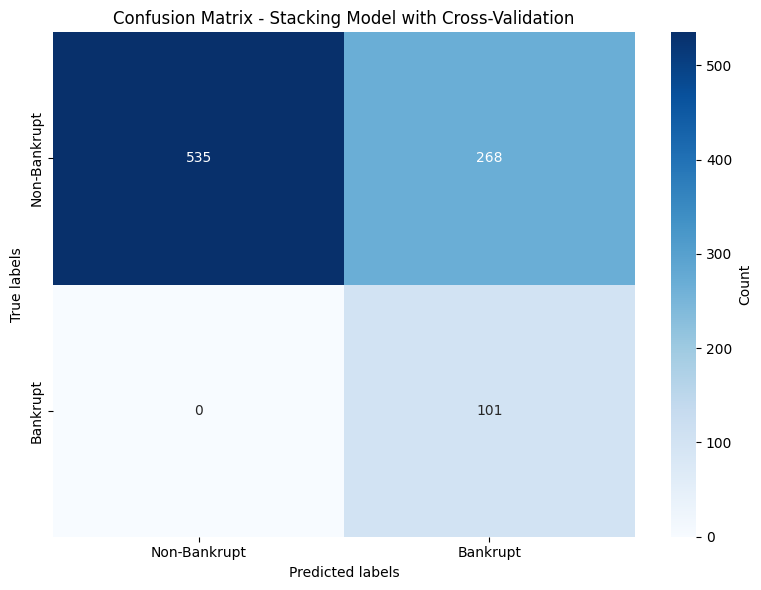


Detailed Classification Report (CV Model):
              precision    recall  f1-score   support

Non-Bankrupt       1.00      0.67      0.80       803
    Bankrupt       0.27      1.00      0.43       101

    accuracy                           0.70       904
   macro avg       0.64      0.83      0.61       904
weighted avg       0.92      0.70      0.76       904



In [174]:
from sklearn.metrics import recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_cv = clf_cv.predict(X)

print("="*80)
print("MINORITY CLASS (Bankrupt? = 1) RECALL EVALUATION")
print("="*80)

# Recall with cross-validation
recall_cv = recall_score(y, y_pred_cv, pos_label=1)
tn, fp, fn, tp = confusion_matrix(y, y_pred_cv).ravel()
recall_formula_cv = tp / (fn + tp)

print(f"\nModel WITH Cross-Validation:")
print(f"  Recall (sklearn): {recall_cv:.4f}")
print(f"  Recall Formula TP/(FN+TP): {recall_formula_cv:.4f}")
print(f"  Confusion Matrix: TP={tp}, FN={fn}, FP={fp}, TN={tn}")

# Create confusion matrix for cross-validation
cm_cv = confusion_matrix(y, y_pred_cv)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, fmt='g', ax=ax, cmap='Blues', cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix - Stacking Model with Cross-Validation')
ax.xaxis.set_ticklabels(['Non-Bankrupt', 'Bankrupt'])
ax.yaxis.set_ticklabels(['Non-Bankrupt', 'Bankrupt'])

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("Detailed Classification Report (CV Model):")
print(f"{'='*80}")
print(classification_report(y, y_pred_cv, target_names=['Non-Bankrupt', 'Bankrupt']))

## Summary of dimensionality experiments

| Dimentions | Method used for reduction | Recall of minority class |
|--|--|--|
| 93 |  None | 1 | 
| 72 | Variance filter | 1 |
| 40 | Variance filter | 1 |
| 13 | Variance filter | 1 |
| 4 | PCA | 1 |
| 3 | PCA | 0.35 |
| 2 | Variance filter | 1 |
| 2 | Variance -> 13 & PCA -> 1 | 0.92 |
| 1 | Variance filter | 0.69 |
| 1 | Variance -> 2 & PCA -> 1 | 1 |

We obtained a recall of the minority class of **1 (100%)** using **one** feature as the input of the stacking model